# Atividade prática: Mineração de Dados - Semana 06

Notebook criado para acompanhar as atividades práticas da Semana 06, apresentadas pela disciplina de **Mineração de Dados** da **UNIVESP**.

## Objetivos da Semana 06:

Utilizar o algoritmo **Apriori** para identificar regras de associação em uma base de dados de compras de uma padaria.

## Exercícios:

Gere a lista dos itens mais vendidos e menos vendidos. Em seguida, use os valores de suporte de 4% (0.04) e confiança de 40% (0.4) para gerar as regras de associação.

### Base de Dados:
https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/main/cesta_padaria.csv

### Sobre o dataframe:

Os dados apresentados são de uma padaria "The Bread Basket", que fica em Edinburgh, na Escócia. Os dados foram modificados para facilitar o uso neste exercício, e o dataframe original se encontra neste [link](https://www.kaggle.com/code/nandinibagga/apriori-algorithm/data).

### Descrição dos atributos:

Existem 94 colunas, cada uma corresponde a um produto e cada linha representa uma transação. Quando o produto faz parte de uma transação, a célula recebe o nome do produto, caso contrário o valor é nulo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!pip -qq install apyori
import apyori # A biblioteca apyori é uma implementação do algoritmo Apriori para mineração de regras de associação.

  Preparing metadata (setup.py) ... done


In [4]:
url = 'https://raw.githubusercontent.com/higoramario/univesp-com360-mineracao-dados/main/cesta_padaria.csv'
df = pd.read_csv(url)
df.head(10)

/tmp/ipython-input-4140763682.py:2: DtypeWarning: Columns (0,5,8,9,10,12,16,18,20,27,31,33,34,36,38,39,41,42,44,46,52,53,54,56,59,63,64,66,67,68,69,70,71,76,80,81,82,84,89,90,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


,adjustment,afternoon with the baker,alfajores,argentina night,art tray,bacon,baguette,bakewell,bare popcorn,basket,...,the bart,the nomad,tiffin,toast,truffles,tshirt,valentine's card,vegan feast,vegan mincepie,victorian sponge
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Entendendo os itens (produtos distintos) existentes na base de dados:

* `total_itens = ...`: O resultado das operações abaixo (lista de itens únicos e ordenados) é armazenado na variável `total_itens`;
* `df.melt()`: Esta função 'desempilha' o DataFrame. A função `melt()` transforma as colunas de produtos em uma única coluna chamada 'value', onde cada entrada é um item comprado ou NaN;
* `['value']`: A coluna 'value' agora contém todos os nomes dos itens de todas as transações;
* `.dropna()`: Remove todas as entradas NaN (que representam itens não comprados) da coluna 'value', deixando apenas os nomes dos produtos que realmente apareceram em alguma transação;
* `.sort_values()`: Organiza os nomes dos produtos restantes em ordem alfabética.
* `total_itens.nunique()`: Conta quantos itens distintos (únicos) existem nessa lista;
* `total_itens.unique()`: Retorna um array contendo cada nome de produto distinto, sem repetições;
* `print(f'O total de produtos distintos é: {total_itens.nunique()}, sendo eles: \n', total_itens.unique())`: Finalmente, esta linha imprime uma mensagem formatada mostrando o número total de produtos distintos encontrados e, em seguida, lista todos esses produtos.

In [11]:
total_itens = df.melt()['value'].dropna().sort_values()
print(f'O total de produtos distintos é: {total_itens.nunique()}, sendo eles: \n', total_itens.unique())

O total de produtos distintos é: 94, sendo eles: 
 ['adjustment' 'afternoon with the baker' 'alfajores' 'argentina night'
 'art tray' 'bacon' 'baguette' 'bakewell' 'bare popcorn' 'basket'
 'bowl nic pitt' 'bread' 'bread pudding' 'brioche and salami' 'brownie'
 'cake' 'caramel bites' 'cherry me dried fruit' 'chicken sand'
 'chicken stew' 'chimichurri oil' 'chocolates' 'christmas common' 'coffee'
 'coffee granules' 'coke' 'cookies' 'crepes' 'crisps'
 'drinking chocolate spoons' 'duck egg' 'dulce de leche' 'eggs'
 "ella's kitchen pouches" 'empanadas' 'extra salami or feta' 'fairy doors'
 'farm house' 'focaccia' 'frittata' 'fudge' 'gift voucher'
 'gingerbread syrup' 'granola' 'hack the stack' 'half slice monster'
 'hearty & seasonal' 'honey' 'hot chocolate' 'jam' 'jammie dodgers'
 'juice' 'keeping it local' 'kids biscuit' 'lemon and coconut' 'medialuna'
 'mighty protein' 'mineral water' 'mortimer' 'muesli' 'muffin'
 'my-5 fruit shoot' 'nomad bag' 'olum & polenta' 'panatone' 'pastry'
 'pick

Lista de itens mais e menos vendidos:

In [8]:
qtde_itens = total_itens.value_counts()
qtde_itens

,count
value,
coffee,4528
bread,3097
tea,1350
cake,983
pastry,815
...,...
gift voucher,1
raw bars,1
polenta,1


Itens mais vendidos:

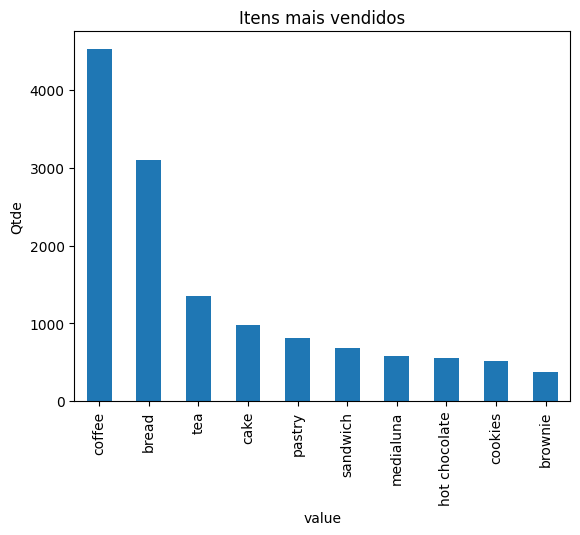

In [22]:
mais_vendido = qtde_itens.nlargest(10).plot(kind="bar") # Seleciona os 10 itens mais vendidos e cria um gráfico de barras
mais_vendido.set_title("Itens mais vendidos")
mais_vendido.set_ylabel("Qtde")
plt.show()

Itens menos vendidos:

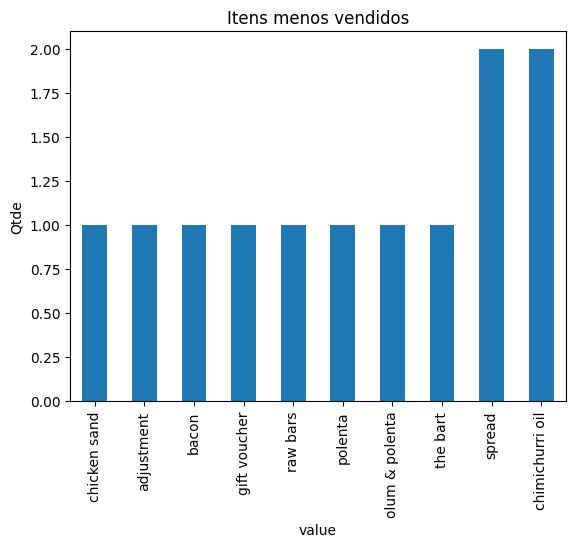

In [21]:
menos_vendido = qtde_itens.nsmallest(10).plot(kind="bar") # Seleciona os 10 itens menos vendidos e cria um gráfico de barras
menos_vendido.set_title("Itens menos vendidos")
menos_vendido.set_ylabel("Qtde")
plt.show()

No algoritmo Apriori, é necessário haver pelo menos 2 itens em cada transação, portanto, transações que possuem somente 1 produto precisam ser eliminadas.

Primeiro, é verificado quantos itens não nulos existem nas transações.

* `df.notna()`: Esta parte verifica cada célula do DataFrame. Para cada célula que contém um valor (não é nula), ela retorna `True`. Para cada célula vazia (NaN), ela retorna `False`. O resultado é um novo DataFrame, mas preenchido com valores booleanos (`True/False`);
* `.apply(sum, axis=1)`:
    * `.apply(sum, ...)`: Aplica a função `sum` (soma) sobre o DataFrame booleano resultante do passo anterior;
    * `axis=1:` EsIndica que a soma deve ser realizada por linha. Em contextos numéricos, `True` é tratado como 1 e `False` como 0. Portanto, somar os valores `True` em cada linha equivale a contar quantos itens não nulos existem em cada transação (linha).
* `itens_n_nulos` = ...: O resultado dessa operação, que é uma série contendo a quantidade de itens não nulos para cada linha (transação), é armazenado na variável `itens_n_nulos`.

In [12]:
itens_n_nulos = df.notna().apply(sum, axis=1)

Após isso, as transações que possuem mais de um item são separadas:

* `df[itens_n_nulos > 1]`: Esta parte filtra o DataFrame original, selecionando apenas as linhas (que representam as transações) onde a contagem de itens não nulos (itens_n_nulos) é maior que 1;

* `for _, linha in ... .iterrows()`: Ele então itera sobre cada uma dessas transações filtradas. _ ignora o índice da linha, e linha representa os dados daquela transação específica;

* `linha.dropna()`: Para cada linha (transação), `dropna()` remove todos os valores nulos (NaN). Isso significa que ele pega apenas os nomes dos produtos que realmente foram comprados naquela transação;

* `set(...)`: Os produtos restantes de cada linha são então convertidos em um set (conjunto). Um conjunto é uma coleção de itens únicos, o que é útil para o Apriori, pois a ordem dos itens dentro de uma transação não importa e itens duplicados são contados apenas uma vez;

* `transacao_mais_item = [...]`: Toda essa lógica é encapsulada em uma 'list comprehension' (compreensão de lista), que cria eficientemente uma nova lista chamada transacao_mais_item. Cada elemento dessa lista é um conjunto de produtos de uma transação que continha mais de um item;




In [13]:
transacao_mais_item = [set(linha.dropna()) for _, linha in df[itens_n_nulos > 1].iterrows()]
transacao_mais_item[:5] # verifica as 5 primeiras transações

[{'cookies', 'hot chocolate', 'jam'},
 {'bread', 'coffee', 'pastry'},
 {'medialuna', 'muffin', 'pastry'},
 {'coffee', 'medialuna', 'pastry', 'tea'},
 {'bread', 'pastry'}]

O tamanho da base de dados diminuiu, conforme pode ser visto com a função `len()`:

In [14]:
len(df)

9465

In [15]:
len(transacao_mais_item)

5517

Utilizando o algoritmo Apriori:

* `minsup = 0.04`: Esta linha define o suporte mínimo (min_support) como 0.04, ou seja, 4%. O suporte é uma métrica que indica a frequência com que um conjunto de itens (ou um único item) aparece nas transações. Para uma regra ser considerada relevante, seus itens devem aparecer em pelo menos 4% de todas as transações;

* `minconf = 0.4`: Esta linha define a confiança mínima (min_confidence) como 0.4, ou seja, 40%. A confiança mede a probabilidade de um item Y ser comprado quando um item X já foi comprado. Se a confiança for de 40%, significa que em 40% das vezes que os itens do antecedente (o que está antes da seta -->) foram comprados, o item do consequente (o que está depois da seta) também foi comprado;

* `regras_associacao = apyori.apriori(transacao_mais_item, min_support=minsup, min_confidence=minconf)`: A função apriori da biblioteca apyori é chamada.
    * `transacao_mais_item`: É a lista de transações (onde cada transação é um conjunto de itens) que foi filtrada para incluir apenas aquelas com mais de um item;
    * `min_support=minsup` e `min_confidence=minconf`: São os limites de suporte e confiança definidos acima;

*O resultado são as regras de associação que atendem a esses critérios, armazenadas na variável `regras_associacao`.*

* `for regra in regras_associacao:`: Este loop itera sobre cada uma das regras de associação encontradas pelo algoritmo Apriori;

    * `itens = list(regra.items)`: Para cada regra, esta linha extrai os itens que compõem a regra (tanto o antecedente quanto o consequente) e os converte em uma lista. Por exemplo, se a regra é 'Pão e Café', itens pode ser ['bread', 'coffee'];

    * `print(...):` Finalmente, esta linha formata e imprime cada regra de associação:

        * `{itens[:-1]} --> [{itens[-1]}]`: Mostra a regra no formato de antecedente e consequente. itens[:-1] pega todos os itens, exceto o último, que representam o antecedente. `[{itens[-1]}]` pega o último item, que é o consequente;
        * `Suporte: {regra.support:.3f}`: Exibe o valor de suporte da regra, formatado para três casas decimais.
        * `Confiança: {regra.ordered_statistics[0].confidence:.3f}:` Exibe o valor de confiança da regra, também formatado para três casas decimais. `ordered_statistics[0]` é usado para acessar a confiança da relação antecedente-consequente específica da regra.

In [18]:
minsup = 0.04
minconf = 0.4
regras_associacao = apyori.apriori(transacao_mais_item, min_support=minsup, min_confidence=minconf)

for regra in regras_associacao:
  itens = list(regra.items)
  print(
      f"{itens[:-1]} --> [{itens[-1]}]  Suporte: {regra.support:.3f}"
      f"  Confiança: {regra.ordered_statistics[0].confidence:.3f}"
  )

[] --> [coffee]  Suporte: 0.604  Confiança: 0.604
['coffee'] --> [bread]  Suporte: 0.154  Confiança: 0.447
['cake'] --> [coffee]  Suporte: 0.094  Confiança: 0.586
['coffee'] --> [cookies]  Suporte: 0.048  Confiança: 0.568
['coffee'] --> [hot chocolate]  Suporte: 0.051  Confiança: 0.580
['coffee'] --> [medialuna]  Suporte: 0.060  Confiança: 0.631
['coffee'] --> [pastry]  Suporte: 0.082  Confiança: 0.600
['coffee'] --> [sandwich]  Suporte: 0.066  Confiança: 0.591
['coffee'] --> [tea]  Suporte: 0.086  Confiança: 0.412
['coffee'] --> [toast]  Suporte: 0.041  Confiança: 0.737
